# Model Training & Cluster Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

import warnings
warnings.filterwarnings('ignore')

## 1. Load Processed Data

In [2]:
# PCA-transformed data for clustering
pca_df = pd.read_csv("../datasets/processed_pca.csv")
X_pca = pca_df.values

# Encoded features for cluster characterization
df_features = pd.read_csv("../datasets/processed_features.csv")

print(f"PCA data shape:  {X_pca.shape}")
print(f"Features shape:  {df_features.shape}")

PCA data shape:  (2236, 3)
Features shape:  (2236, 18)


## 2. Cluster Selection — Elbow Method

In [3]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print(f"Optimal K (Elbow Method): {optimal_k}")

Optimal K (Elbow Method): 4


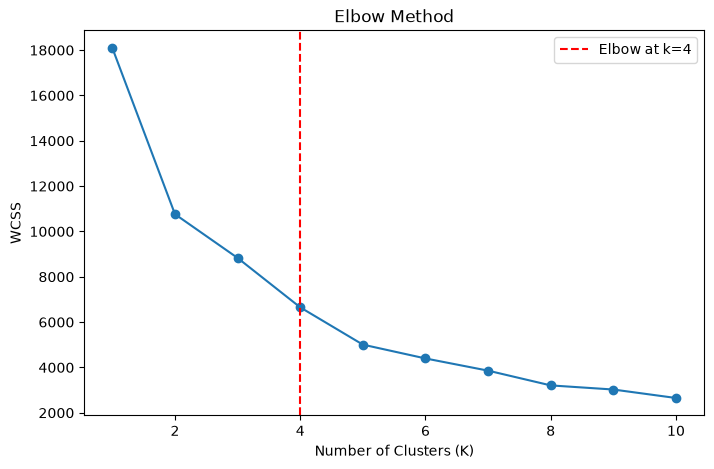

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.axvline(x=optimal_k, color="r", linestyle="--", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.legend()
plt.show()

## 3. Cluster Selection — Silhouette Score

In [5]:
s_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    s_scores.append(score)

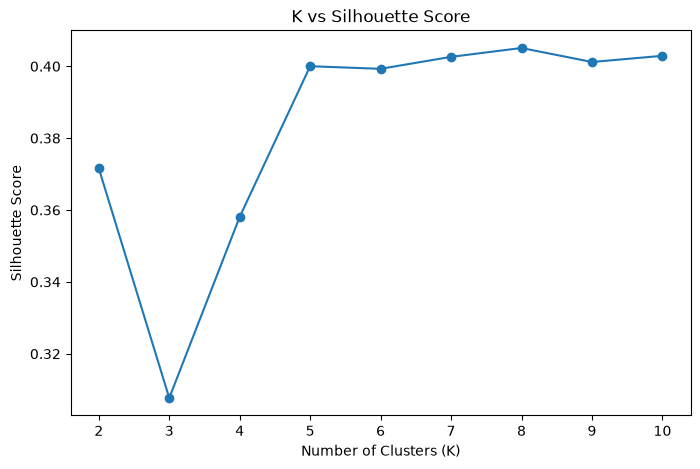

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), s_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K vs Silhouette Score")
plt.show()

### Combined Elbow + Silhouette Plot

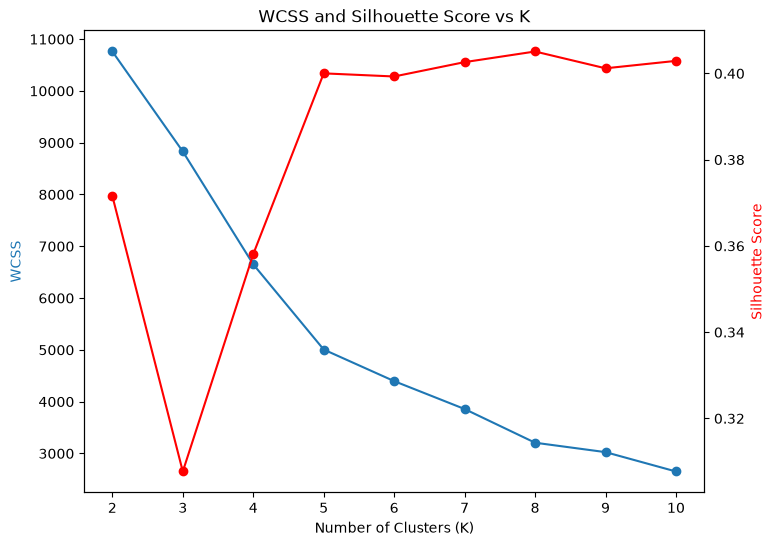

In [7]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

# WCSS for k=2..10 (skip k=1 to align with silhouette scores)
ax1.plot(k_range, wcss[1:], marker="o", label="WCSS")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("WCSS", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(k_range, s_scores, marker="o", color="red", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="red")

plt.title("WCSS and Silhouette Score vs K")
plt.show()

## 4. K-Means Clustering

Using the optimal K determined by the Elbow Method.

In [8]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

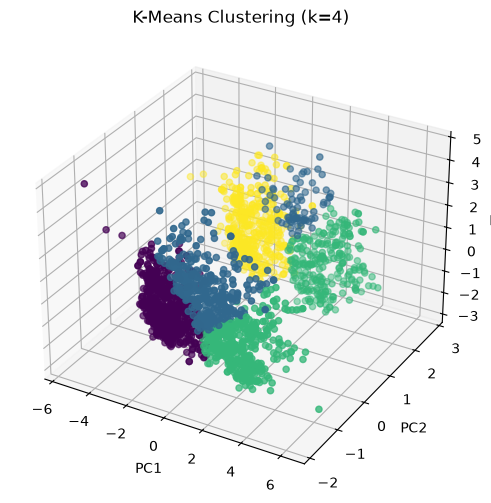

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels, cmap="viridis")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"K-Means Clustering (k={optimal_k})")
plt.show()

## 5. Agglomerative Clustering

In [10]:
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
agg_labels = agg.fit_predict(X_pca)

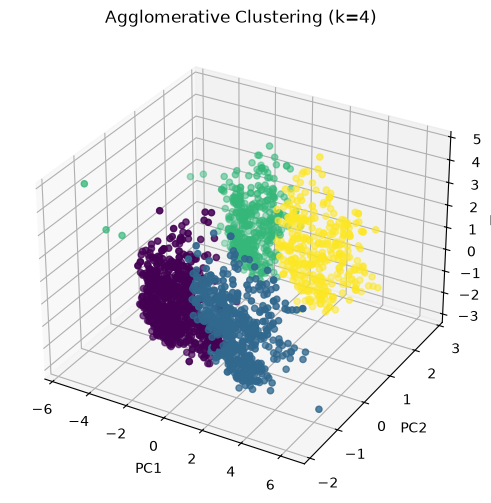

In [11]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agg_labels, cmap="viridis")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"Agglomerative Clustering (k={optimal_k})")
plt.show()

## 6. Cluster Characterization

Using Agglomerative Clustering labels for analysis.

In [12]:
df_features["clusters"] = agg_labels

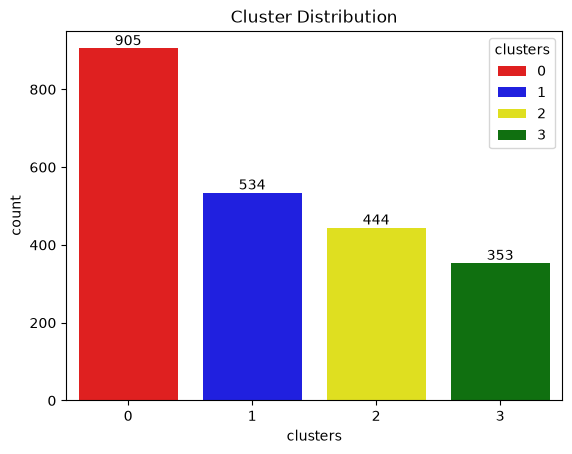

In [13]:
c_pal = ["Red", "Blue", "Yellow", "Green"]

ax = sns.countplot(
    x=df_features["clusters"],
    palette=c_pal,
    hue=df_features["clusters"],
    legend=True
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Cluster Distribution")
plt.show()

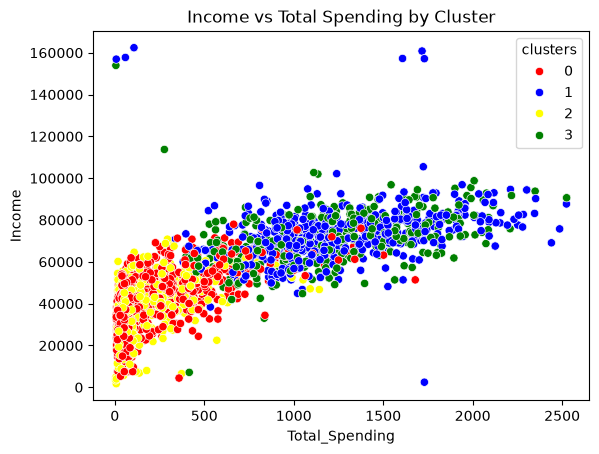

In [14]:
# Income vs Spending by Cluster

sns.scatterplot(
    x=df_features["Total_Spending"],
    y=df_features["Income"],
    hue=df_features["clusters"],
    palette=c_pal
)
plt.title("Income vs Total Spending by Cluster")
plt.show()

## 7. Cluster Summary

In [15]:
# Count and percentage per cluster
cluster_counts = df_features["clusters"].value_counts().sort_index()
cluster_pct = (cluster_counts / len(df_features) * 100).round(1)

# Average of key features per cluster
cluster_means = df_features.groupby("clusters").mean().round(2)

# Combine into one table
cluster_means.insert(0, "Count", cluster_counts)
cluster_means.insert(1, "% of Total", cluster_pct)

cluster_means


,Count,% of Total,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
clusters,,,,,,,,,,,,,,,,,,,,
0,905,40.5,39680.58,48.91,2.59,3.15,0.97,4.14,6.31,0.01,0.08,55.67,342.94,221.96,1.24,0.51,0.34,0.15,0.00,1.00
1,534,23.9,72808.45,49.20,1.96,5.69,5.50,8.66,3.58,0.01,0.17,59.49,369.72,1236.59,0.51,0.47,0.46,0.07,0.00,1.00
2,444,19.9,36960.14,48.32,2.59,2.71,0.84,3.62,6.66,0.01,0.14,55.69,338.78,165.70,1.27,0.49,0.38,0.13,0.99,0.01
3,353,15.8,70722.68,50.50,1.86,5.79,5.01,8.43,3.73,0.01,0.32,58.93,376.28,1190.39,0.46,0.54,0.39,0.07,1.00,0.00


### Cluster Interpretation

In [16]:
overall_avg = df_features.drop(columns="clusters").mean()
results = []

for cluster_id in sorted(df_features["clusters"].unique()):

    count = int(cluster_means.loc[cluster_id, "Count"])

    pct = cluster_means.loc[cluster_id, "% of Total"]

    cluster_avg = cluster_means.loc[cluster_id].drop(
        ["Count", "% of Total"]
    )

    for feature in cluster_avg.index:

        cluster_val = cluster_avg[feature]
        overall_val = overall_avg[feature]

        if overall_val == 0:
            continue

        diff_pct = (
            (cluster_val - overall_val)
            / abs(overall_val)
        ) * 100

        if abs(diff_pct) > 15:

            direction = "Higher" if diff_pct > 0 else "Lower"

            results.append({
                "Cluster": cluster_id,
                "Customers": count,
                "% of Total": pct,
                "Feature": feature,
                "Cluster Average": cluster_val,
                "Overall Average": overall_val,
                "Difference %": diff_pct,
                "Direction": direction
            })

comparison_df = pd.DataFrame(results)
comparison_df["Cluster Average"] = (
    comparison_df["Cluster Average"].round(2)
)

comparison_df["Overall Average"] = (
    comparison_df["Overall Average"].round(2)
)

comparison_df["Difference %"] = (
    comparison_df["Difference %"].round(2)
)

comparison_df["% of Total"] = (
    comparison_df["% of Total"].round(2)
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

comparison_df

,Cluster,Customers,% of Total,Feature,Cluster Average,Overall Average,Difference %,Direction
0,0,905,40.5,Income,39680.58,51952.61,-23.62,Lower
1,0,905,40.5,NumWebPurchases,3.15,4.09,-22.94,Lower
2,0,905,40.5,NumCatalogPurchases,0.97,2.66,-63.58,Lower
3,0,905,40.5,NumStorePurchases,4.14,5.80,-28.57,Lower
4,0,905,40.5,NumWebVisitsMonth,6.31,5.32,18.63,Higher
5,0,905,40.5,Response,0.08,0.15,-46.44,Lower
6,0,905,40.5,Total_Spending,221.96,605.99,-63.37,Lower
7,0,905,40.5,Total_Children,1.24,0.95,30.42,Higher
8,0,905,40.5,Education_Undergraduate,0.15,0.11,31.53,Higher
9,0,905,40.5,Living_With_Alone,0.00,0.36,-100.00,Lower
